In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../data/transactions.csv")

In [2]:
df.columns

Index(['Date', 'Transaction Description', 'Category', 'Amount', 'Type'], dtype='str')

In [3]:
df.head()

,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1500 non-null   str    
 1   Transaction Description  1500 non-null   str    
 2   Category                 1500 non-null   str    
 3   Amount                   1500 non-null   float64
 4   Type                     1500 non-null   str    
dtypes: float64(1), str(4)
memory usage: 58.7 KB


In [5]:
df['Category'].value_counts()

Category
Rent                165
Travel              160
Utilities           157
Health & Fitness    152
Shopping            150
Food & Drink        149
Salary              146
Entertainment       143
Investment          142
Other               136
Name: count, dtype: int64

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df['Month'] = df['Date'].dt.to_period('M')

In [8]:
df[['Date','Month']].head()

,Date,Month
0,2020-01-02,2020-01
1,2020-01-02,2020-01
2,2020-01-04,2020-01
3,2020-01-05,2020-01
4,2020-01-13,2020-01


In [9]:
expenses = df[df['Type'] == 'Expense']

In [10]:
expenses.shape

(1222, 6)

In [11]:
category_spend = (
    expenses
    .groupby('Category')['Amount']
    .sum()
    .sort_values(ascending=False)
)

print(category_spend)

Category
Travel              169497.79
Rent                162075.39
Food & Drink        159493.39
Salary              149053.55
Entertainment       148165.47
Shopping            146880.75
Utilities           146833.97
Health & Fitness    145194.06
Name: Amount, dtype: float64


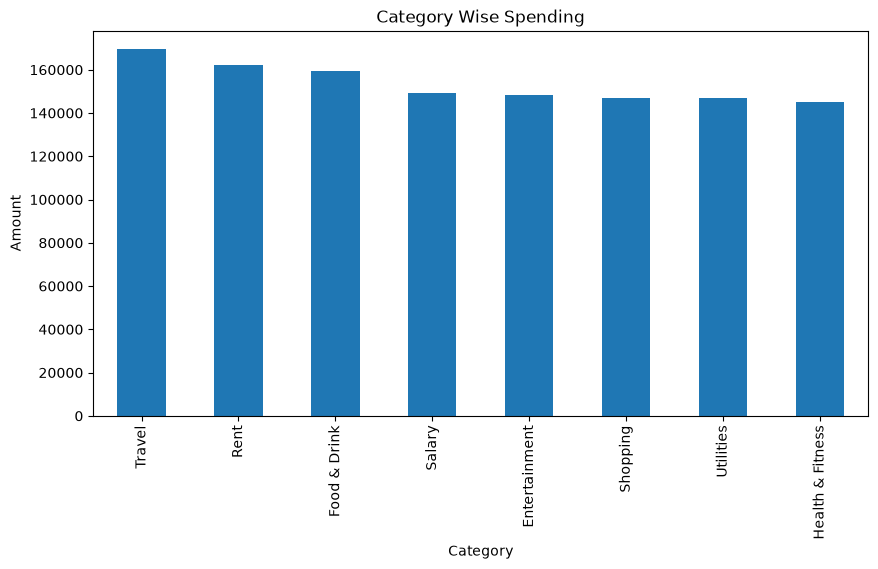

In [12]:
category_spend.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Category Wise Spending")
plt.ylabel("Amount")
plt.show()

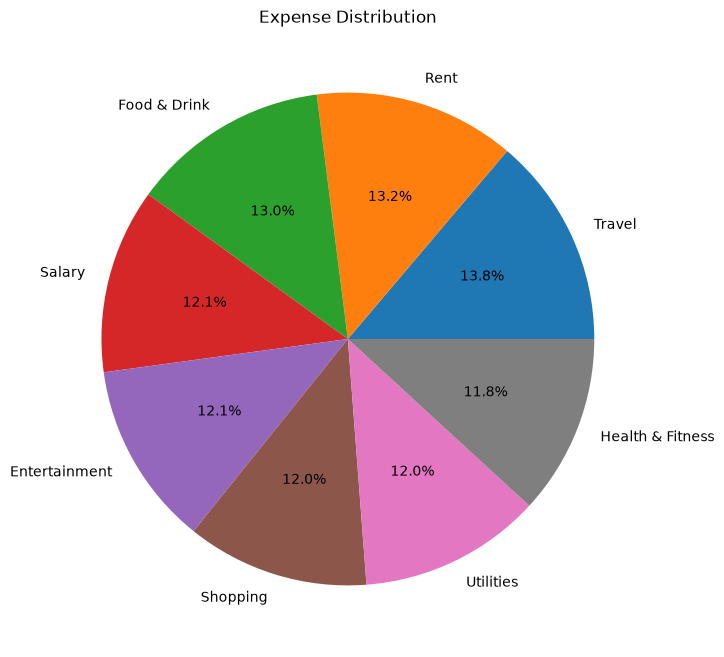

In [13]:
category_spend.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.ylabel('')
plt.title("Expense Distribution")
plt.show()

In [14]:
monthly_spend = (
    expenses
    .groupby('Month')['Amount']
    .sum()
)

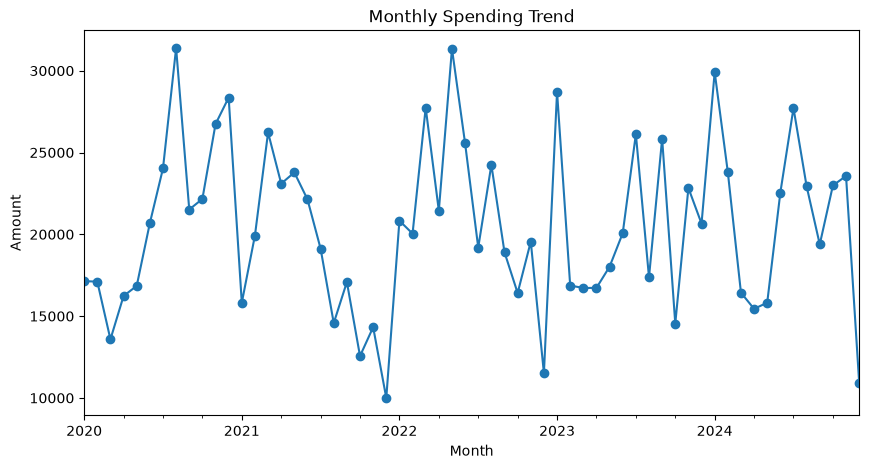

In [15]:
monthly_spend.plot(
    marker='o',
    figsize=(10,5)
)

plt.title("Monthly Spending Trend")
plt.ylabel("Amount")
plt.show()

In [16]:
merchant_spend = (
    expenses
    .groupby('Transaction Description')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

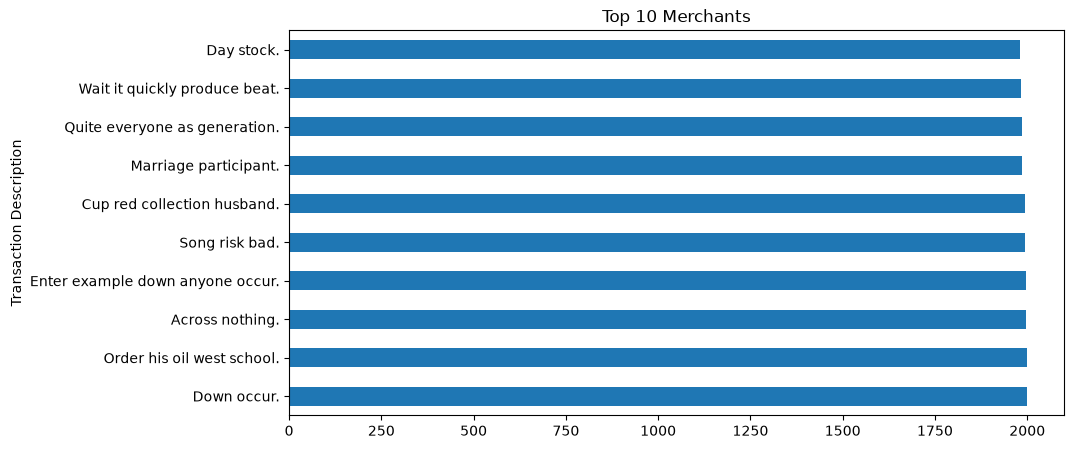

In [17]:
merchant_spend.plot(
    kind='barh',
    figsize=(10,5)
)

plt.title("Top 10 Merchants")
plt.show()

In [18]:
budget = {
    'Food': 20000,
    'Transport': 10000,
    'Shopping': 15000,
    'Entertainment': 8000,
    'Bills': 12000
}

In [19]:
budget_df = pd.DataFrame(
    budget.items(),
    columns=['Category','Budget']
)

In [20]:
actual_df = category_spend.reset_index()
actual_df.columns = ['Category','Actual']

In [21]:
comparison = pd.merge(
    budget_df,
    actual_df,
    on='Category',
    how='left'
)

comparison['Difference'] = (
    comparison['Budget']
    - comparison['Actual']
)

comparison

,Category,Budget,Actual,Difference
0,Food,20000,NaN,NaN
1,Transport,10000,NaN,NaN
2,Shopping,15000,146880.75,-131880.75
3,Entertainment,8000,148165.47,-140165.47
4,Bills,12000,NaN,NaN


In [22]:
top3 = category_spend.head(3)

print(top3)

Category
Travel          169497.79
Rent            162075.39
Food & Drink    159493.39
Name: Amount, dtype: float64


In [23]:
total_expense = expenses['Amount'].sum()

print("Total Expense:", total_expense)

print("\nTop Categories:")

print(category_spend.head(5))

Total Expense: 1227194.37

Top Categories:
Category
Travel           169497.79
Rent             162075.39
Food & Drink     159493.39
Salary           149053.55
Entertainment    148165.47
Name: Amount, dtype: float64


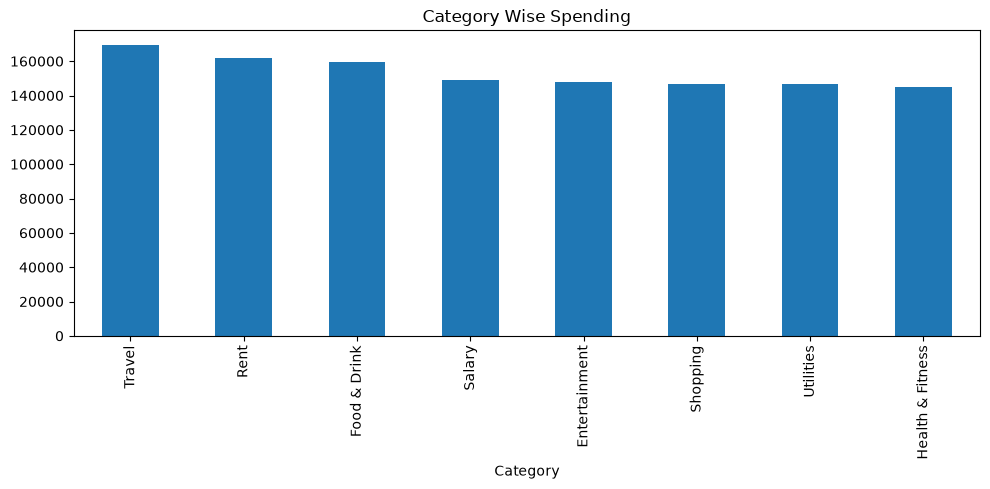

In [24]:
# Category Spending
plt.figure(figsize=(10,5))
category_spend.plot(kind='bar')
plt.title("Category Wise Spending")
plt.tight_layout()
plt.savefig("../charts/category_spending.png")
plt.show()

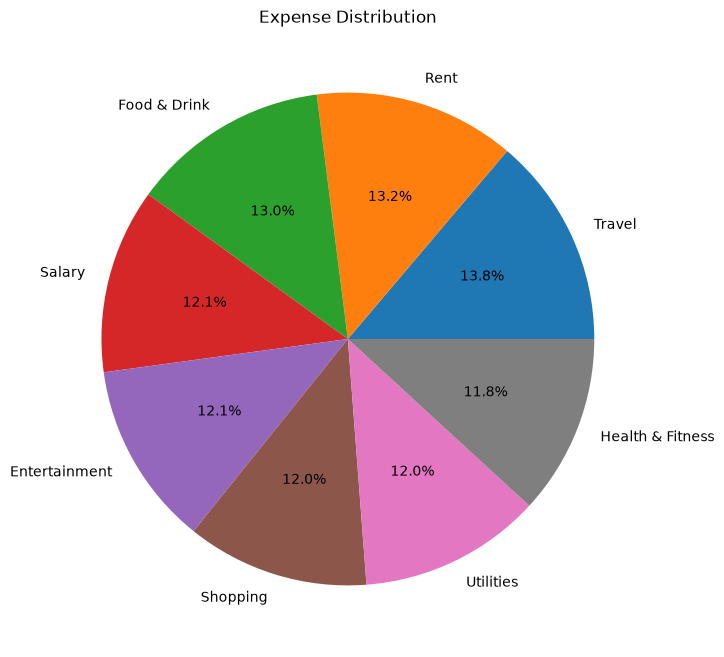

In [25]:
# Pie Chart
plt.figure(figsize=(8,8))
category_spend.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel("")
plt.title("Expense Distribution")
plt.savefig("../charts/expense_distribution.png")
plt.show()


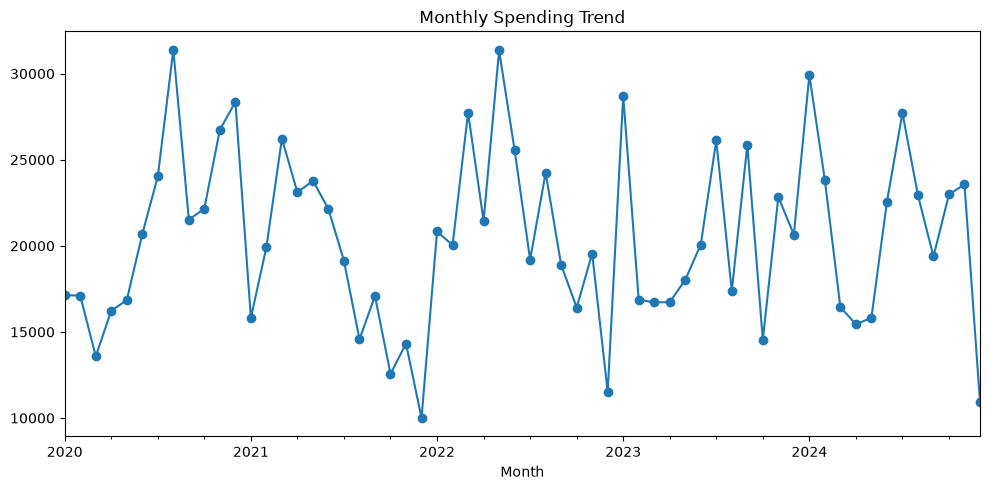

In [27]:
# Monthly Trend
plt.figure(figsize=(10,5))
monthly_spend.plot(marker='o')
plt.title("Monthly Spending Trend")
plt.tight_layout()
plt.savefig("../charts/monthly_trend.png")
plt.show()

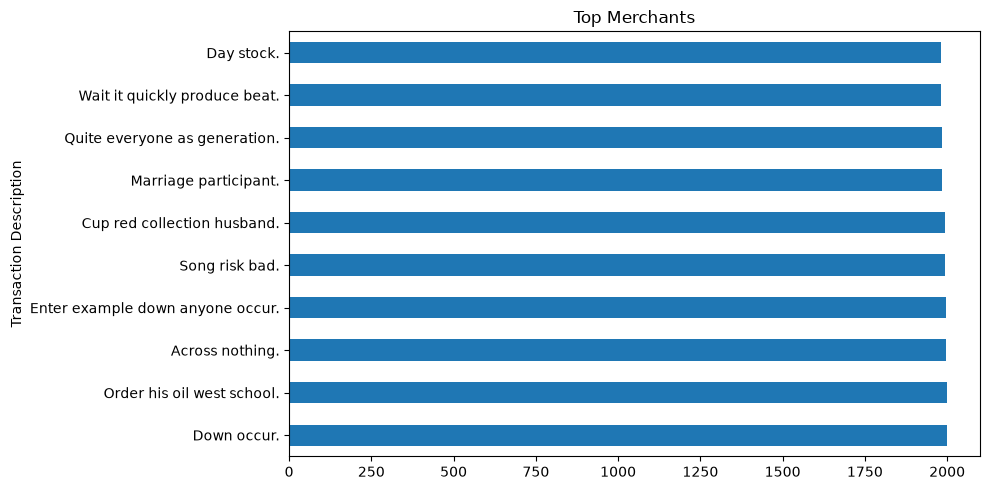

In [28]:
# Top Merchants
plt.figure(figsize=(10,5))
merchant_spend.plot(kind='barh')
plt.title("Top Merchants")
plt.tight_layout()
plt.savefig("../charts/top_merchants.png")
plt.show()